# System benchmark — latency and memory of every pipeline stage

Deliverable from the proposal: *"a validation notebook measuring the computational latency and memory consumption of each module stage."*

We run both pipeline orders on nine test conversations (one per overlap × noise condition) and record, for each stage: wall-clock time, real-time factor (processing time ÷ audio length — below 1 means faster than real time), and peak GPU memory. Models are loaded and warmed up first, so the numbers measure processing, not loading.

In [1]:
import sys, os, json, time
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

torch 2.5.1+cu121 | CUDA: True | NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [2]:
# Chart style: thin marks, hairline grid, fixed categorical colour order (blue, orange, aqua).
C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "grey": "#8a8984", "ink": "#0b0b0b", "ink2": "#52514e"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#c9c8c3", "axes.grid": True, "grid.color": "#ebeae6", "grid.linewidth": 0.8,
                     "axes.axisbelow": True, "font.size": 10, "axes.titlesize": 11, "axes.labelcolor": C["ink2"],
                     "xtick.color": C["ink2"], "ytick.color": C["ink2"], "legend.frameon": False})

## 1 · Load both pipelines (models are loaded once and shared)

In [3]:
from whospoke.pipeline import Pipeline, make_asr
from whospoke.__main__ import tuned_diarizer
from whospoke.audio import load, SR

asr = make_asr("indicconformer")
pipes = {
    "Order A (separate → diarize → ASR)": Pipeline("A", diarizer=tuned_diarizer("A", "spectral"), asr_model=asr),
    "Order B (diarize → separate overlaps → ASR)": Pipeline("B", diarizer=tuned_diarizer("B", "spectral"), asr_model=asr),
}
for p in pipes.values():
    p.warmup()
print("ready")

C:\Users\darsh\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fetching 404 files:   0%|          | 0/404 [00:00<?, ?it/s]

Fetching 404 files:  60%|██████    | 244/404 [00:00<00:00, 2401.11it/s]

Fetching 404 files: 100%|██████████| 404/404 [00:00<00:00, 2285.51it/s]

C:\whospoke-data\venv\Lib\site-packages\asteroid\models\base_models.py:114: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  conf = torch.load(cached_model, map_location="cpu")

C:\whospoke-data\venv\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


C:\whospoke-data\venv\Lib\site-packages\pyannote\audio\utils\reproducibility.py:74: ReproducibilityWarning: TensorFloat-32 (TF32) has been disabled as it might lead to reproducibility issues and lower accuracy.
It can be re-enabled by calling
   >>> import torch
   >>> torch.backends.cuda.matmul.allow_tf32 = True
   >>> torch.backends.cudnn.allow_tf32 = True
See https://github.com/pyannote/pyannote-audio/issues/1370 for more details.

  warnings.warn(


ready


## 2 · Model sizes

In [4]:
from whospoke import vad
from whospoke.diarization import _embedding_model, default_device
def n_params(m):
    return sum(p.numel() for p in m.parameters()) / 1e6
sep = pipes["Order B (diarize → separate overlaps → ASR)"].separator._model
seg = vad._pipelines(None)[0]._segmentation.model
emb = _embedding_model(default_device()).model_
rows = [("Conv-TasNet (separation)", n_params(sep)), ("pyannote segmentation-3.0 (VAD + overlap)", n_params(seg)),
        ("WeSpeaker ResNet-34 (speaker embeddings)", n_params(emb))]
try:
    rows.append((f"{asr.name} (ASR)", asr.num_parameters() / 1e6))
except Exception:
    pass
pd.DataFrame(rows, columns=["model", "parameters (millions)"])

,model,parameters (millions)
0,Conv-TasNet (separation),5.067
1,pyannote segmentation-3.0 (VAD + overlap),1.473
2,WeSpeaker ResNet-34 (speaker embeddings),6.634


## 3 · Run on one conversation per condition

In [5]:
from whospoke.paths import SYNTH, conversation
idx = pd.read_csv(SYNTH / "test/index.csv")
subset = idx[idx.group.isin([0, 1])].groupby(["overlap_level", "noise"]).head(1)
records = []
for name, p in pipes.items():
    for r in subset.itertuples():
        wav = load(conversation(r.path) / "mixture.wav")
        res = p.run(wav)
        for stage in ("separation", "diarization", "asr"):
            records.append({"pipeline": name, "conversation": r.id, "stage": stage, "audio_s": res.duration_s,
                            "seconds": res.timings[stage], "gpu_peak_mb": res.gpu_peak_mb.get(stage, np.nan)})
        records.append({"pipeline": name, "conversation": r.id, "stage": "total", "audio_s": res.duration_s,
                        "seconds": res.timings["total"], "gpu_peak_mb": max(res.gpu_peak_mb.values())})
bench = pd.DataFrame(records)
bench["rtf"] = bench.seconds / bench.audio_s
bench.to_csv(ROOT / "results/benchmark_stages.csv", index=False)
summary = bench.groupby(["pipeline", "stage"]).agg(seconds=("seconds", "mean"), rtf=("rtf", "mean"),
                                                   gpu_peak_mb=("gpu_peak_mb", "max")).round(3)
summary

C:\whospoke-data\venv\Lib\site-packages\pyannote\audio\models\blocks\pooling.py:104: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\ReduceOps.cpp:1823.)
  std = sequences.std(dim=-1, correction=1)


seconds    rtf  \
pipeline                                    stage                         
Order A (separate → diarize → ASR)          asr            5.228  0.076   
                                            diarization    1.108  0.017   
                                            separation     1.456  0.021   
                                            total          7.803  0.113   
Order B (diarize → separate overlaps → ASR) asr            3.349  0.048   
                                            diarization    0.630  0.009   
                                            separation     0.367  0.005   
                                            total          4.357  0.062   

                                                         gpu_peak_mb  
pipeline                                    stage                     
Order A (separate → diarize → ASR)          asr               4367.5  
                                            diarization       4365.5  
                                            separation        4365.5  
                                            total             4367.5  
Order B (diarize → separate overlaps → ASR) asr               4479.5  
                                            diarization       4419.5  
                                            separation        4419.5  
                                            total             4479.5

## 4 · Where does the time go?

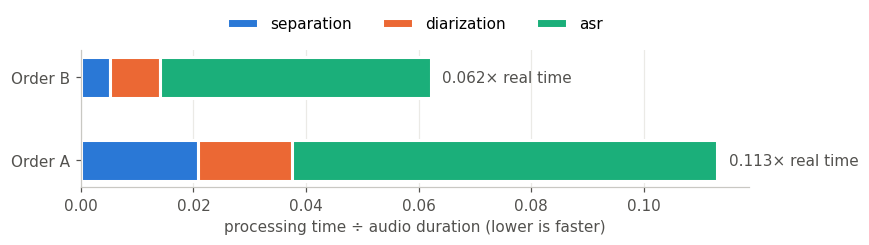

In [6]:
stages = ["separation", "diarization", "asr"]
colors = [C["blue"], C["orange"], C["aqua"]]
fig, ax = plt.subplots(figsize=(8, 2.6))
names = list(pipes)
for i, name in enumerate(names):
    left = 0
    for s, col in zip(stages, colors):
        v = bench[(bench.pipeline == name) & (bench.stage == s)].rtf.mean()
        ax.barh(i, v, left=left, color=col, height=0.5, edgecolor="white", linewidth=2, label=s if i == 0 else None)
        left += v
    ax.text(left + 0.002, i, f"{left:.3f}× real time", va="center", color=C["ink2"])
ax.set_yticks(range(len(names)), [n.split(" (")[0] for n in names])
ax.set_xlabel("processing time ÷ audio duration (lower is faster)")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.35))
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.savefig(ROOT / "results/figures/latency_by_stage.png", dpi=200, bbox_inches="tight"); plt.show()

## 5 · Peak GPU memory per stage

In [7]:
mem = bench[bench.stage != "total"].groupby(["stage", "pipeline"]).gpu_peak_mb.max().unstack()
mem.round(0)

pipeline,Order A (separate → diarize → ASR),Order B (diarize → separate overlaps → ASR)
stage,,
asr,4368.0,4480.0
diarization,4366.0,4420.0
separation,4366.0,4420.0


## 6 · Does the cost grow linearly with audio length?

We chain test conversations into 1-, 2-, 4- and 8-minute recordings and time Order B.

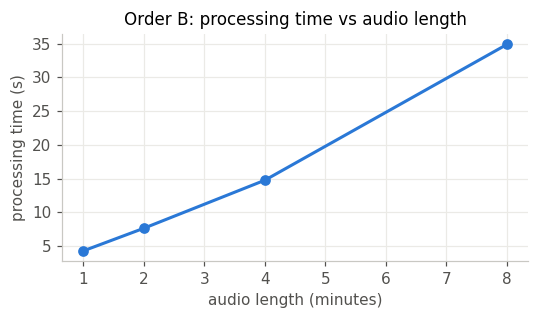

,minutes,seconds,rtf,gpu_peak_mb
0,1,4.294,0.072,4479.5
1,2,7.646,0.064,4479.5
2,4,14.763,0.062,4541.5
3,8,34.878,0.073,4541.5


In [8]:
long = np.concatenate([load(conversation(p) / "mixture.wav") for p in idx.path[:8]])
p = pipes["Order B (diarize → separate overlaps → ASR)"]
scaling = []
for minutes in (1, 2, 4, 8):
    x = long[: int(minutes * 60 * SR)]
    res = p.run(x)
    scaling.append({"minutes": minutes, "seconds": res.timings["total"], "rtf": res.timings["total"] / (len(x) / SR),
                    "gpu_peak_mb": max(res.gpu_peak_mb.values())})
scaling = pd.DataFrame(scaling); scaling.to_csv(ROOT / "results/benchmark_scaling.csv", index=False)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(scaling.minutes, scaling.seconds, color=C["blue"], lw=2, marker="o", ms=6)
ax.set_xlabel("audio length (minutes)"); ax.set_ylabel("processing time (s)")
ax.set_title("Order B: processing time vs audio length")
plt.tight_layout(); plt.savefig(ROOT / "results/figures/latency_scaling.png", dpi=200, bbox_inches="tight"); plt.show()
scaling

## Summary

The tables above are saved to `results/benchmark_stages.csv` and `results/benchmark_scaling.csv`; the figures to `results/figures/`. The headline numbers are quoted in `docs/RESULTS.md`.